# Clase 4 — Modelos Multimodales y Aprendizaje Auto-supervisado

<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Google Colab"/></a>

> Para usarlo en Google Colab: sube este notebook a Colab o guárdalo en Drive y ábrelo desde `Archivo > Abrir notebook`.

Ya vimos Transformers para **texto** (Clase 2) y **visión** (Clase 3). Ahora los **unimos**: modelos que relacionan imágenes y lenguaje (**CLIP, BLIP, LLaVA**), generación con **difusión**, y el paradigma que lo hace posible a escala —el **aprendizaje auto-supervisado (SSL)**— con sus fronteras actuales (**DINO, SAM, JEPA**).

**Objetivos.** Al terminar deberías poder:
1. Explicar las tres familias del **SSL**: enmascarado, contrastivo y auto-destilación.
2. Describir **CLIP** (aprendizaje contrastivo imagen-texto) y su **clasificación zero-shot**.
3. Comparar **BLIP-2** y **LLaVA**: cómo conectan un encoder visual con un LLM.
4. Entender la **difusión latente** (Stable Diffusion) como generador texto→imagen.
5. Conocer las **fronteras**: DINO/DINOv2, SAM y los *world models* (JEPA / V-JEPA 2).

**Formato (≈ 3 horas):** teoría + práctica. Activa **GPU**.

| Bloque | Tema | ~min |
|---|---|---|
| 0 | Aprendizaje auto-supervisado (SSL) | 20 |
| 1 | CLIP: imagen + texto contrastivo | 25 |
| 2 | BLIP-2 y LLaVA: visión + LLM | 20 |
| — | *Descanso* | 10 |
| 3 | Difusión latente (Stable Diffusion) | 20 |
| 4 | Fronteras: DINO, SAM, JEPA | 25 |
| 5 | 🧪 Práctica: CLIP zero-shot, retrieval y DINO | 45 |

## Bloque 0 · Aprendizaje auto-supervisado (SSL)

In [1]:
# Setup
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [2]:
!pip install -q transformers

Etiquetar datos es caro; datos **sin** etiquetar hay infinitos. El **aprendizaje auto-supervisado (SSL)** aprende inventando una *tarea pretexto* cuyas "etiquetas" salen de los **propios datos**. Ya lo vimos varias veces en el curso — son las **tres grandes familias** del SSL:

- **Predicción enmascarada:** ocultar parte de la entrada y reconstruirla. → BERT (Clase 2), Masked Autoencoders.
- **Contrastiva:** acercar representaciones de vistas relacionadas y alejar las no relacionadas. → SimCLR, **CLIP**.
- **Auto-destilación:** una red aprende a imitar otra versión de sí misma, sin etiquetas. → **DINO**.

El SSL es lo que permite **preentrenar modelos fundacionales** con datos masivos sin anotación — la base de todo lo que sigue.

<img src="https://raw.githubusercontent.com/ivansipiran/Deep-Learning/main/infografias/M4/07_SSL_02.png" width="1080">

<sub>Las tres familias del aprendizaje auto-supervisado: enmascarado, contrastivo y auto-destilación.</sub>

## Bloque 1 · CLIP: imagen + texto contrastivo

**CLIP** (OpenAI, 2021) aprende una representación **conjunta** de imágenes y texto. Dos encoders:
- **Visual encoder** (ResNet o **ViT**) → convierte la imagen en un vector.
- **Text encoder** (Transformer) → convierte el texto en un vector.

Ambos se proyectan al **mismo espacio latente**. Se entrena con **aprendizaje contrastivo** sobre 400M de pares (imagen, texto) de la web, sin etiquetas: para cada *batch* de $N$ pares, se maximiza la similitud coseno de los pares correctos y se minimiza la de los $N^2-N$ incorrectos.

<img src="https://raw.githubusercontent.com/ivansipiran/Deep-Learning/main/img/m4_05_clip.png" width="720">

<sub>CLIP: encoders de imagen y texto entrenados con pérdida contrastiva para alinear pares (imagen, texto) en un espacio compartido.</sub>

$$ \text{sim}(I_i, T_j) = \frac{I_i \cdot T_j}{\lVert I_i\rVert\,\lVert T_j\rVert}, \qquad L = \tfrac{1}{2}\big[\text{CE sobre imágenes} + \text{CE sobre textos}\big] $$

El resultado es poderosísimo: permite **clasificación zero-shot**. Para clasificar una imagen entre unas clases, se escribe cada clase como una frase (*"una foto de un {gato}"*), se codifican con el text encoder, y se elige la de mayor similitud con la imagen. **Sin entrenar un clasificador.**

In [3]:
# Demo conceptual: clasificación zero-shot estilo CLIP (embeddings de juguete ya alineados)
# Se calcula la norma euclidiana y se normaliza el vector dividiendo por esa norma.
def norm(v): return v / v.norm(dim=-1, keepdim=True)
textos = {"un gato": torch.tensor([1.,0.,0.]),
          "un perro": torch.tensor([0.,1.,0.]),
          "un auto":  torch.tensor([0.,0.,1.])}
img_emb = norm(torch.tensor([0.9, 0.1, 0.05]))        # imagen "parecida a gato"
print("Similitud coseno imagen <-> cada texto:")
for t, v in textos.items():
    print(f"  '{t}': {torch.dot(img_emb, norm(v)).item():.3f}")
print("-> Predicción zero-shot:", max(textos, key=lambda t: torch.dot(img_emb, norm(textos[t]))))

Similitud coseno imagen <-> cada texto:
  'un gato': 0.992
  'un perro': 0.110
  'un auto': 0.055
-> Predicción zero-shot: un gato


## Bloque 2 · BLIP-2 y LLaVA: conectar visión con un LLM

CLIP alinea imagen y texto, pero **no genera** texto ni razona. La siguiente generación conecta un **encoder visual** con un **LLM** para *conversar* sobre imágenes (captioning, VQA, razonamiento).

**BLIP-2** (Salesforce, 2022) introduce el **Q-Former**: un Transformer ligero con *queries* aprendibles que, mediante atención cruzada, **extrae de la imagen solo lo relevante** y lo traduce al espacio del LLM. Así reutiliza un ViT congelado y un LLM congelado (Flan-T5, OPT), entrenando solo el puente.

<img src="https://raw.githubusercontent.com/ivansipiran/Deep-Learning/main/img/m4_06_blip2.png" width="720">

<sub>BLIP-2: un ViT congelado, un Q-Former que selecciona features visuales, y un LLM congelado que genera texto.</sub>

**LLaVA** (2023) lleva la idea al paradigma de los LLM de instrucciones: proyecta las características de un **CLIP-ViT** al espacio de tokens de un LLM (**LLaMA/Vicuña**) con una simple **proyección lineal**, y se afina con datos de conversación multimodal generados por GPT-4. El resultado es un **asistente visual** que responde preguntas sobre imágenes.

<img src="https://raw.githubusercontent.com/ivansipiran/Deep-Learning/main/img/m4_07_llava.png" width="640">

<sub>LLaVA: CLIP-ViT + proyección lineal + LLM → un asistente conversacional multimodal.</sub>

| Modelo | Encoder visual | LLM | Puente | Razonamiento |
|---|---|---|---|---|
| CLIP | CLIP-ViT | — | — | No |
| BLIP-2 | ViT | Flan-T5 | Q-Former | Sí |
| LLaVA | CLIP-ViT | LLaMA | Lineal | Sí |

## Bloque 3 · Difusión latente (Stable Diffusion)

Para **generar** imágenes desde texto, la familia dominante es la de **modelos de difusión**. La idea: aprender a **quitar ruido** paso a paso. En entrenamiento se añade ruido a una imagen hasta volverla ruido puro; el modelo aprende a **invertir** el proceso. En inferencia, se parte de ruido y se *denoisea* hasta obtener una imagen.

**Latent Diffusion / Stable Diffusion** (StabilityAI, 2022) hace la difusión **no sobre píxeles**, sino en un **espacio latente comprimido** (vía un autoencoder VAE) — mucho más barato. Tres piezas:
- **VAE:** codifica imagen ↔ latente $z$.
- **U-Net denoiser:** aprende a quitar ruido de $z$.
- **Condicionamiento textual:** un encoder de texto (**CLIP**/T5) guía la generación mediante **atención cruzada**.

<img src="https://raw.githubusercontent.com/ivansipiran/Deep-Learning/main/img/m4_04_stable_diffusion.png" width="720">

<sub>Stable Diffusion: difusión en el espacio latente del VAE, con una U-Net condicionada por texto (CLIP) vía atención cruzada.</sub>

Fíjate que **el Transformer sigue presente**: el condicionamiento por texto y la atención cruzada usan exactamente los mecanismos de las Clases 1-2. Variantes: SDXL (mayor resolución), ControlNet y DreamBooth (control y personalización).

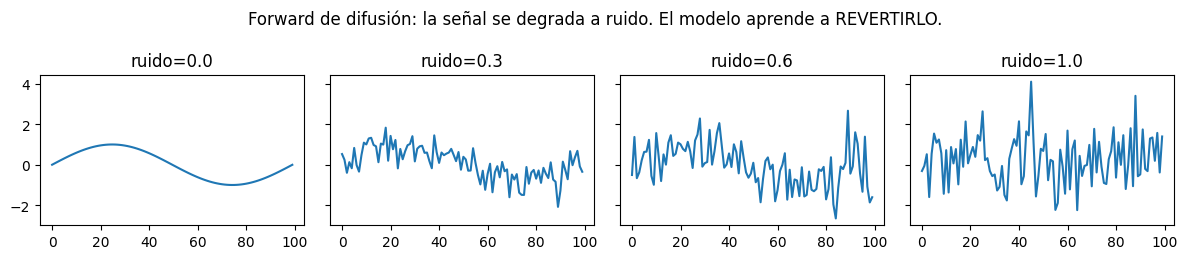

In [4]:
# Demo: el proceso forward de difusión (agregar ruido progresivamente) sobre una señal 1D
x0 = torch.sin(torch.linspace(0, 6.28, 100))        # "imagen" de juguete (una onda)
fig, axs = plt.subplots(1, 4, figsize=(12, 2.6), sharey=True)
for ax, beta in zip(axs, [0.0, 0.3, 0.6, 1.0]):
    xt = (1-beta)**0.5 * x0 + beta**0.5 * torch.randn_like(x0)
    ax.plot(xt); ax.set_title(f"ruido={beta:.1f}")
plt.suptitle("Forward de difusión: la señal se degrada a ruido. El modelo aprende a REVERTIRLO.")
plt.tight_layout(); plt.show()

## Bloque 4 · Fronteras: DINO, SAM y JEPA

### DINO / DINOv2 — ViT auto-supervisados
**DINO** (*self-DIstillation with NO labels*, Meta 2021) entrena un ViT **sin etiquetas** con un esquema *student–teacher*: el **teacher** no se entrena por gradiente, sino que es un **promedio móvil exponencial (EMA)** del student. A cada red se le muestran *crops* distintos de la misma imagen, y el student aprende a imitar al teacher.

<img src="https://raw.githubusercontent.com/ivansipiran/Deep-Learning/main/img/m4_10_dino.png" width="640">

<sub>DINO: el student y el teacher (EMA del student) ven crops distintos de la misma imagen; el student imita al teacher, sin etiquetas.</sub>

El EMA es una técnica para mantener una segunda copia del teacher, cuyos pesos son un promedio suavizado de los pesos del student. El teacher no se entrena directamente con backpropagation. En cambio, sus pesos se actualizan a partir de los pesos del student.

Se entrena con una técnica que es el "stop gradiente", donde solo el student actualiza sus pesos y se propragan al teacher a través del EMA (el EMA sí actualiza los pesos del teacher).

Una **propiedad emergente** notable: los mapas de atención de un ViT-DINO **segmentan objetos** sin que nadie se lo enseñara. **DINOv2** (2023) escaló la idea a ~142M de imágenes: un **modelo fundacional de visión** cuyos *features* sirven —sin fine-tuning— para clasificación, segmentación y profundidad.

In [5]:
# Demo: la actualización EMA del teacher en DINO
torch.manual_seed(0)
lam = 0.99
theta_student = torch.randn(5)
theta_teacher = theta_student.clone()
for step in range(5):
    theta_student = theta_student + 0.3*torch.randn(5)               # el student "aprende"
    theta_teacher = lam*theta_teacher + (1-lam)*theta_student        # teacher = EMA del student
    print(f"paso {step}: ||teacher - student|| = {(theta_teacher-theta_student).norm():.3f}")
print("El teacher sigue lenta y establemente al student (no se entrena directamente).")

paso 0: ||teacher - student|| = 0.556
paso 1: ||teacher - student|| = 0.762
paso 2: ||teacher - student|| = 1.052
paso 3: ||teacher - student|| = 1.091
paso 4: ||teacher - student|| = 1.035
El teacher sigue lenta y establemente al student (no se entrena directamente).


### SAM — Segment Anything
**SAM** (Meta, 2023) es un modelo fundacional **promptable** para **segmentación**: dado un *prompt* (un punto, una caja), devuelve la máscara del objeto, **zero-shot**, sobre imágenes nunca vistas. Separa un **image encoder** pesado (ViT, se ejecuta una vez) de un **mask decoder** ligero (por cada prompt).

<img src="https://raw.githubusercontent.com/ivansipiran/Deep-Learning/main/img/m4_11_sam.png" width="640">

<sub>SAM: un image encoder (ViT) pesado + un decoder ligero que, dado un prompt, produce la máscara del objeto.</sub>

### World Models y JEPA
Un LLM predice texto; para **actuar en el mundo físico** un agente necesita un **world model**. La apuesta de Yann LeCun (Meta) es **JEPA** (*Joint Embedding Predictive Architecture*): en vez de predecir **píxeles**, predice **representaciones** en el espacio latente — concentrándose en la estructura que importa, no en detalles impredecibles.

En otras palabras, los world models aprenden una representación interna del mundo para poder predecir como evolucionará el entorno. En lugar de limitarse a reconocer patrones (como clasificar imágenes), intentan responder preguntas cómo:
* ¿Qué ocurrirá si realizo esta acción?
* ¿Cómo cambiaría la escena en el siguiente instante?
* ¿Qué consecuencias tendrá una secuencia de acciones?

El término fue popularizado por **David Ha y Jürgen Schmidhuber**, en su artículo _World Models_ publicando en 2018.

<img src="https://raw.githubusercontent.com/ivansipiran/Deep-Learning/main/infografias/M4/JEPA.png" width="680">

<sub>JEPA: un context encoder y un predictor estiman la representación de la parte oculta, comparada —en latente— con la del target encoder (un EMA).</sub>

La línea de modelos: **I-JEPA** (imágenes, 2023) → **V-JEPA** (video, 2024) → **V-JEPA 2** (jun. 2025), un world model de **1.200 millones de parámetros** preentrenado con **más de 1 millón de horas** de video. Logra resultados de punta en comprensión del movimiento y, con muy pocos datos de robots, habilita **planificación robótica zero-shot** en entornos nuevos.

In [6]:
# Demo: JEPA predice REPRESENTACIONES, no píxeles
torch.manual_seed(0)
contexto_emb = torch.randn(8)               # representación del contexto (parte visible)
objetivo_emb = torch.randn(8)               # representación objetivo (del target encoder EMA)
predictor    = torch.nn.Linear(8, 8)
loss_latente = F.mse_loss(predictor(contexto_emb), objetivo_emb)
print("Loss de JEPA = distancia en el espacio LATENTE:", round(loss_latente.item(), 3))
print("Los modelos generativos, en cambio, miden el error PÍXEL a PÍXEL en el espacio de la imagen.")
print("Predecir en latente evita malgastar capacidad en detalles impredecibles.")

Loss de JEPA = distancia en el espacio LATENTE: 0.613
Los modelos generativos, en cambio, miden el error PÍXEL a PÍXEL en el espacio de la imagen.
Predecir en latente evita malgastar capacidad en detalles impredecibles.


| Modelo | Dataset(s) principal(es) | Cantidad aproximada | Unidad | Tipo de supervisión |
|---------|--------------------------|--------------------:|--------|---------------------|
| **CLIP** | Dataset privado de OpenAI (Internet) | **400 M** | Pares imagen–texto | Supervisión débil (imagen–texto) |
| **BLIP** | COCO, Visual Genome, CC3M, CC12M, SBU, LAION | **14 M** (BLIP base) / **129 M** (BLIP-Large) | Imágenes–texto | Supervisado (captions) |
| **BLIP-2** | COCO, VG, CC3M, CC12M, SBU + LAION | **129 M** | Imágenes–texto | Supervisado (captions) |
| **LLaVA 1.0** | COCO convertido mediante GPT-4 | **158 K** | Instrucciones multimodales | Supervisado (Instruction Tuning) |
| **Stable Diffusion v1** | LAION-2B-en (subconjuntos filtrados) | Hasta **2.32 B** pares disponibles | Pares imagen–texto | Supervisión débil |
| **DINO** | ImageNet-1K | **1.28 M** | Imágenes | Self-Supervised |
| **DINOv2** | LVD-142M | **142 M** | Imágenes | Self-Supervised |
| **SAM** | SA-1B | **11 M imágenes** + **1 B máscaras** | Imágenes + máscaras | Supervisado |
| **SAM 2** | SA-V | **50.9 K videos**, **35.5 M máscaras**, **642.6 K masklets** | Videos | Supervisado |
| **SAM 3** | SA-Co/HQ, SA-Co/SYN, SA-Co/EXT, SA-Co/VIDEO | **5.2 M imágenes**, **52.5 K videos**, **52 M máscaras**, **1.4 B máscaras sintéticas** | Imágenes + videos + conceptos | Supervisado |
| **JEPA** | — | — | Arquitectura general | Self-Supervised |
| **I-JEPA** | ImageNet-1K | **1.28 M** | Imágenes | Self-Supervised |
| **V-JEPA** | VideoMix2M (HowTo100M, Kinetics, SSv2) | **2 M videos** | Videos | Self-Supervised |
| **V-JEPA 2** | VideoMix22M | **22 M muestras** (>1 M horas de video) | Videos + imágenes | Self-Supervised |
| **V-JEPA 2-AC** | VideoMix22M + DROID | **22 M** + **62 h** de videos robóticos | Videos + acciones | Self-Supervised + Action Conditioning |

## Bloque 5 · 🧪 Práctica: CLIP real

Usamos el **CLIP real** de OpenAI (vía Hugging Face) para: (A) **clasificación zero-shot** de una imagen contra frases arbitrarias, y (B) **retrieval** (buscar, entre varias imágenes, la que mejor coincide con un texto).

In [7]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import requests
clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device).eval()
proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
print("CLIP cargado.")

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP cargado.


### A · Clasificación zero-shot

   99.9%  a photo of cats
    0.1%  a photo of food
    0.0%  a photo of a dog
    0.0%  a photo of a car
    0.0%  a photo of a plane


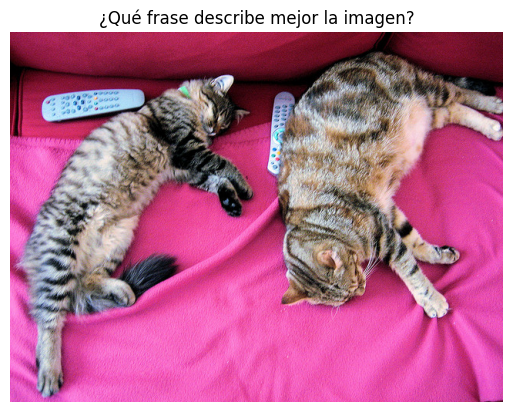

In [8]:
url = "http://images.cocodataset.org/val2017/000000039769.jpg"     # dos gatos en un sofá
img_pil = Image.open(requests.get(url, stream=True).raw).convert("RGB")

clases = ["a photo of cats", "a photo of a dog", "a photo of a car",
          "a photo of a plane", "a photo of food"]
inputs = proc(text=clases, images=img_pil, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    logits = clip(**inputs).logits_per_image      # similitud imagen<->cada texto
    probs = logits.softmax(dim=1)[0]

for c, p in sorted(zip(clases, probs.tolist()), key=lambda z: -z[1]):
    print(f"  {p:6.1%}  {c}")
plt.imshow(img_pil); plt.axis("off"); plt.title("¿Qué frase describe mejor la imagen?"); plt.show()

### B · Retrieval texto → imagen
### 🧩 Ejercicio 1
Dadas **varias** imágenes y **una** consulta de texto, encuentra la imagen que mejor coincide (mayor similitud). Descarga 2-3 imágenes (URLs de COCO), codifícalas con CLIP y compara.

In [ ]:
# TODO: tu solución
...

In [9]:
# @title Solución (retrieval con CLIP)
urls = {
 "gatos":  "http://images.cocodataset.org/val2017/000000039769.jpg",
 "pizza":  "http://images.cocodataset.org/val2017/000000000632.jpg",
 "bus":    "http://images.cocodataset.org/val2017/000000000724.jpg",
}
imgs = {k: Image.open(requests.get(u, stream=True).raw).convert("RGB") for k,u in urls.items()}
consulta = "something you can eat"

inp = proc(text=[consulta], images=list(imgs.values()), return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    sims = clip(**inp).logits_per_text[0]         # similitud del texto con cada imagen
mejor = list(imgs.keys())[sims.argmax().item()]
print(f"Consulta: '{consulta}'  ->  imagen más parecida: '{mejor}'")
for k, s in zip(imgs, sims.tolist()): print(f"  {k}: {s:.1f}")

Consulta: 'something you can eat'  ->  imagen más parecida: 'bus'
  gatos: 19.9
  pizza: 18.3
  bus: 20.5


### 🧩 Ejercicio 2 — Reto (opcional, pesado)
Si tienes tiempo y GPU, genera una imagen desde texto con **Stable Diffusion** usando `diffusers`:
```python
!pip install -q diffusers accelerate
from diffusers import StableDiffusionPipeline
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16).to("cuda")
img = pipe("a photorealistic cat astronaut, digital art").images[0]
img
```
Observa cómo el **prompt de texto** (codificado por CLIP) guía la generación — el mismo mecanismo de atención de todo el curso.

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

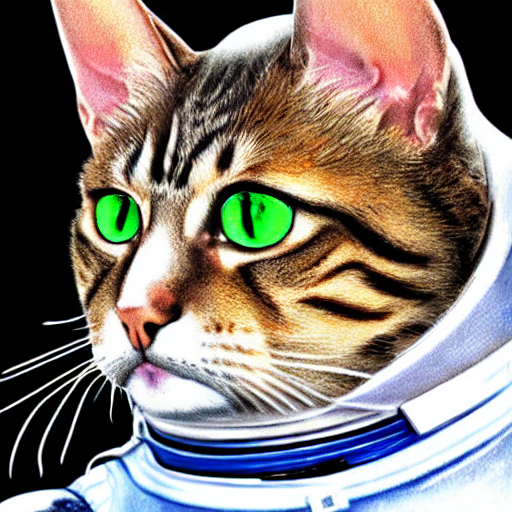

In [10]:
!pip install -q diffusers accelerate
from diffusers import StableDiffusionPipeline
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16).to("cuda")
img = pipe("a photorealistic cat astronaut, digital art").images[0]
img

## Cierre del curso

Cerramos el círculo. En cuatro clases pasamos de un **bloque de atención** implementado a mano a los sistemas que definen la IA de hoy:

1. **Introducción:** atención, self-attention y el bloque Transformer, desde cero.
2. **NLP:** apilar decoders → **LLMs**; muestreo, preentrenamiento, fine-tuning y LoRA.
3. **Visión:** el mismo Transformer sobre parches → **ViT**, jerarquías y atención local.
4. **Multimodal + SSL:** unir visión y lenguaje (**CLIP, BLIP, LLaVA**), generación con **difusión**, y las fronteras (**DINO, SAM, JEPA**).

Un mismo mecanismo —la **atención**— para texto, imágenes, audio y acción. Y un mismo motor —el **aprendizaje auto-supervisado**— para aprender de datos sin etiquetar a escala planetaria. Esa universalidad es, en el fondo, la razón por la que los Transformers cambiaron el campo.

> **Cierre.** Los modelos seguirán cambiando; los **principios** de este curso —atención, representaciones compartidas, predicción como tarea pretexto— seguirán siendo la llave para entender lo que venga.